In [14]:
import qiskit
from qiskit import *
import numpy as np
from qiskit import QuantumRegister, QuantumCircuit, transpile
from qiskit.quantum_info import Statevector    
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session 
from qiskit.quantum_info import state_fidelity
import qiskit.quantum_info as qi
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.providers.fake_provider import *
from qiskit.providers import *
from qiskit_aer import AerSimulator
import qiskit_aer.noise as noise

In [15]:
"""QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="TOKEN",
    overwrite=True
)

service = QiskitRuntimeService()
backend = service.backend("ibm_torino")"""

'QiskitRuntimeService.save_account(\n    channel="ibm_quantum_platform",\n    token="TOKEN",\n    overwrite=True\n)\n\nservice = QiskitRuntimeService()\nbackend = service.backend("ibm_torino")'

In [16]:
m = 3 #qubit di indirizzo + 1 ancilla

n = ((2*(m-1))+ (2*(2**(m-1)))) #qubit di memoria (il doppio perché è in dual rail encoding)


bus = QuantumRegister(1, name='bus')
addr = QuantumRegister(m, name='addr')
qram = QuantumRegister(n, name='qram')
qc = QuantumCircuit(bus,addr,qram)

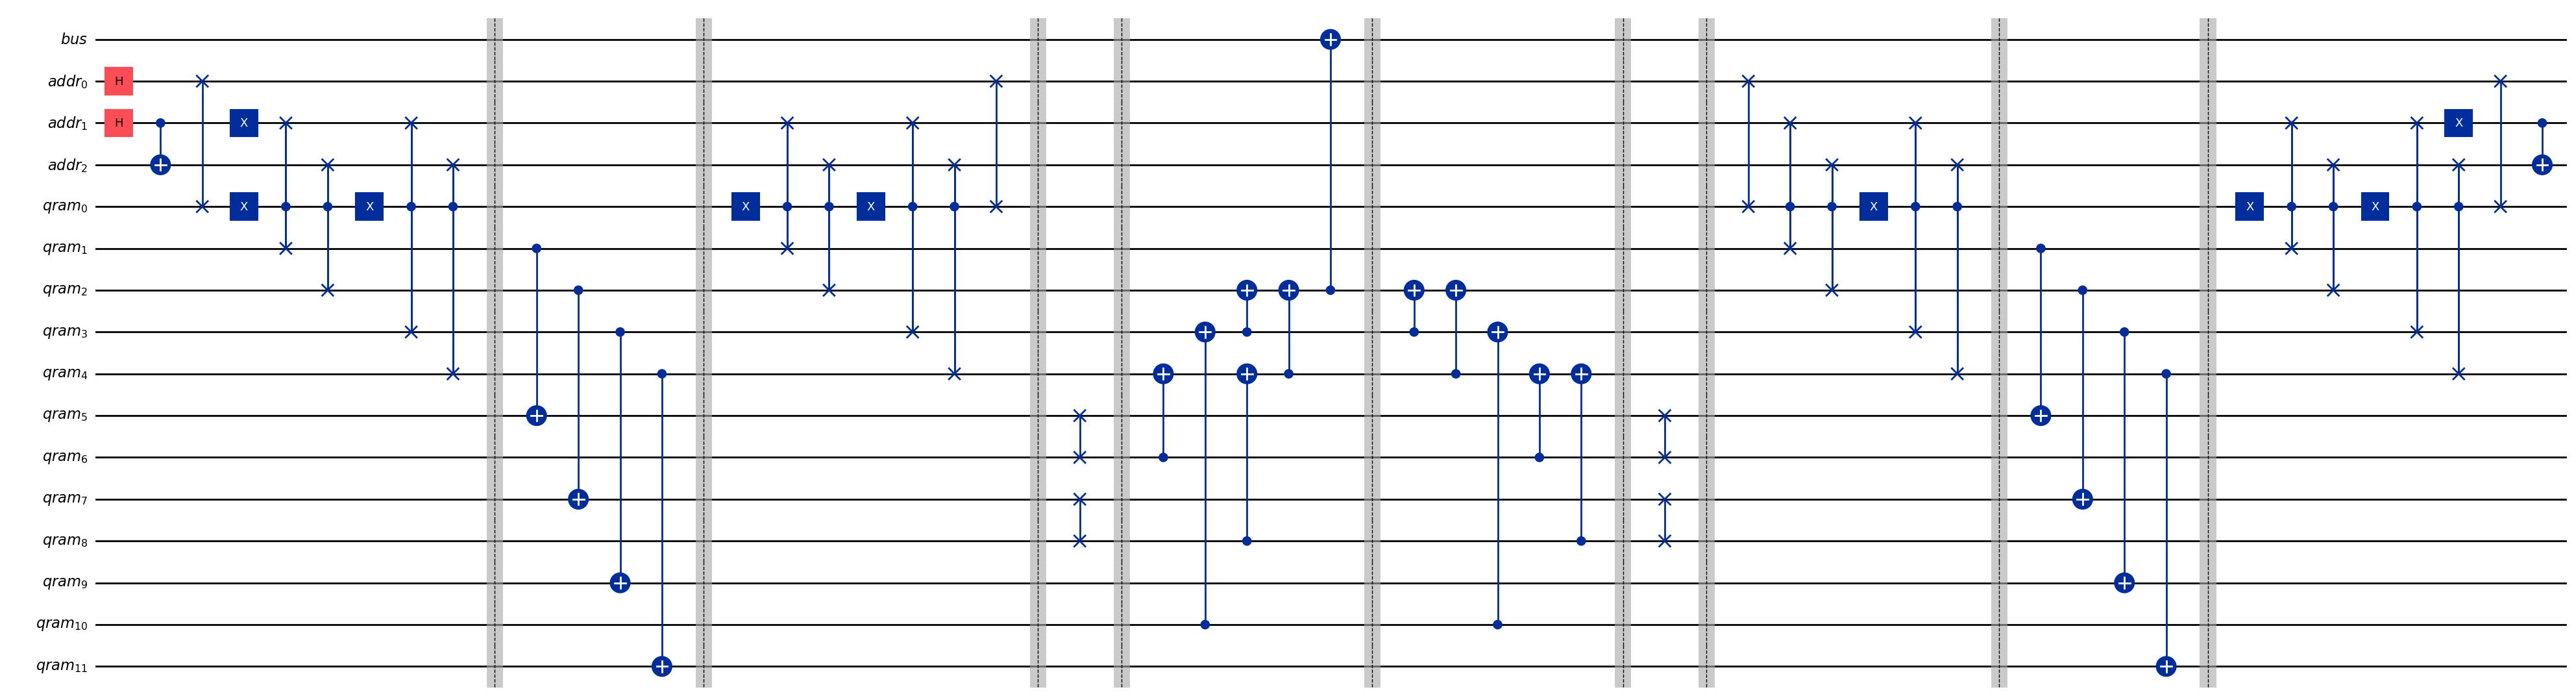

In [17]:
#ADDRESS LOADING

#sovrapposizione degli indirizzi
for i in range (0, m-1):
    qc.h(addr[i])

qc.cx(addr[m-2],addr[m-1]) #ancilla
qc.x(addr[m-2]) 


qc.swap(addr[0],qram[0]) #introduco sovrapposizione negli indirizzi DI MEMORIA (QRAM)

#caricamento degli indirizzi
qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])  #serve per standardizzare 
                                               #l'arrivo all'i-esimo router del secondo banco 
qc.barrier()

for i in range (1, 2*(m-1)+1):        #propaga informazioni alle foglie
    #print(f"i = {i} m+(2*i) = {m + (2*i)}\n")
    qc.cx(qram[i], qram[m+(2*i)])

qc.barrier()

#address recycling

qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    #print(f"i = {i} i+(m-1) = {i+(m-1)}\n")
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])

qc.swap(addr[0],qram[0])

qc.barrier()

#DATA RETRIEVAL

for i in range (1, 2+(2**(m-1)//2), 2):
    qc.swap(qram[2*(m-1)+i], qram[(2*(m-1)+i)+1])
qc.barrier()

qc.cx(qram[6],qram[4])
qc.cx(qram[8],qram[4])
qc.cx(qram[10],qram[3])
qc.cx(qram[3],qram[2])
qc.cx(qram[4],qram[2])


qc.cx(qram[2],bus[0])

qc.barrier()

#uncompute
qc.cx(qram[3],qram[2])
qc.cx(qram[4],qram[2])
qc.cx(qram[6],qram[4])
qc.cx(qram[8],qram[4])
qc.cx(qram[10],qram[3])

qc.barrier()

#UNLOAD

for i in range (1, 2+(2**(m-1)//2), 2):
    qc.swap(qram[2*(m-1)+i], qram[(2*(m-1)+i)+1])
qc.barrier()

qc.swap(addr[0],qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])


qc.barrier()

for i in range (1, 2*(m-1)+1):        
    #print(f"i = {i} m+(2*i) = {m + (2*i)}\n")
    qc.cx(qram[i], qram[m+(2*i)])

qc.barrier()

qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    #print(f"i = {i} i+(m-1) = {i+(m-1)}\n")
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])

qc.swap(addr[0],qram[0])
qc.x(addr[m-2])
qc.cx(addr[m-2],addr[m-1]) 

qc.draw('mpl', fold = -1)

In [18]:
qc.draw()

░                      ░         »
    bus: ────────────────────────────────────░──────────────────────░─────────»
         ┌───┐                               ░                      ░         »
 addr_0: ┤ H ├──────X────────────────────────░──────────────────────░─────────»
         ├───┤      │ ┌───┐                  ░                      ░         »
 addr_1: ┤ H ├──■───┼─┤ X ├─X──────────X─────░──────────────────────░───────X─»
         └───┘┌─┴─┐ │ └───┘ │          │     ░                      ░       │ »
 addr_2: ─────┤ X ├─┼───────┼──X───────┼──X──░──────────────────────░───────┼─»
              └───┘ │ ┌───┐ │  │ ┌───┐ │  │  ░                      ░ ┌───┐ │ »
 qram_0: ───────────X─┤ X ├─■──■─┤ X ├─■──■──░──────────────────────░─┤ X ├─■─»
                      └───┘ │  │ └───┘ │  │  ░                      ░ └───┘ │ »
 qram_1: ───────────────────X──┼───────┼──┼──░───■──────────────────░───────X─»
                               │       │  │  ░   │                  ░         »
 qram_2: ──────────────────────X───────┼──┼──░───┼────■─────────────░─────────»
                                       │  │  ░   │    │             ░         »
 qram_3: ──────────────────────────────X──┼──░───┼────┼────■────────░─────────»
                                          │  ░   │    │    │        ░         »
 qram_4: ─────────────────────────────────X──░───┼────┼────┼────■───░─────────»
                                             ░ ┌─┴─┐  │    │    │   ░         »
 qram_5: ────────────────────────────────────░─┤ X ├──┼────┼────┼───░─────────»
                                             ░ └───┘  │    │    │   ░         »
 qram_6: ────────────────────────────────────░────────┼────┼────┼───░─────────»
                                             ░      ┌─┴─┐  │    │   ░         »
 qram_7: ────────────────────────────────────░──────┤ X ├──┼────┼───░─────────»
                                             ░      └───┘  │    │   ░         »
 qram_8: ────────────────────────────────────░─────────────┼────┼───░─────────»
                                             ░           ┌─┴─┐  │   ░         »
 qram_9: ────────────────────────────────────░───────────┤ X ├──┼───░─────────»
                                             ░           └───┘  │   ░         »
qram_10: ────────────────────────────────────░──────────────────┼───░─────────»
                                             ░                ┌─┴─┐ ░         »
qram_11: ────────────────────────────────────░────────────────┤ X ├─░─────────»
                                             ░                └───┘ ░         »
«                           ░     ░                     ┌───┐ ░                »
«    bus: ──────────────────░─────░─────────────────────┤ X ├─░────────────────»
«                           ░     ░                     └─┬─┘ ░                »
« addr_0: ───────────────X──░─────░───────────────────────┼───░────────────────»
«                        │  ░     ░                       │   ░                »
« addr_1: ─────────X─────┼──░─────░───────────────────────┼───░────────────────»
«                  │     │  ░     ░                       │   ░                »
« addr_2: ─X───────┼──X──┼──░─────░───────────────────────┼───░────────────────»
«          │ ┌───┐ │  │  │  ░     ░                       │   ░                »
« qram_0: ─■─┤ X ├─■──■──X──░─────░───────────────────────┼───░────────────────»
«          │ └───┘ │  │     ░     ░                       │   ░                »
« qram_1: ─┼───────┼──┼─────░─────░───────────────────────┼───░────────────────»
«          │       │  │     ░     ░           ┌───┐┌───┐  │   ░ ┌───┐┌───┐     »
« qram_2: ─X───────┼──┼─────░─────░───────────┤ X ├┤ X ├──■───░─┤ X ├┤ X ├─────»
«                  │  │     ░     ░      ┌───┐└─┬─┘└─┬─┘      ░ └─┬─┘└─┬─┘┌───┐»
« qram_3: ─────────X──┼─────░─────░──────┤ X ├──■────┼────────░───■────┼──┤ X ├»
«                     │     ░     ░ ┌───┐└─┬─┘┌───┐  │        ░        │  └─┬─┘»
« qram_4: ────────────X─────

In [ ]:
import os
import csv

def analyze_and_save(qc, m, filename="qram_metrics.csv"):
    # conta porte
    ops = qc.count_ops()

    h = ops.get('h', 0)
    cx = ops.get('cx', 0)
    cswap = ops.get('cswap', 0)
    swap = ops.get('swap', 0)
    x = ops.get('x', 0)

    G = h + cx + cswap + swap + x

    row = [m, h, cx, cswap, swap, x, G]

    file_exists = os.path.isfile(filename)

    with open(filename, "a", newline="") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow(["m", "H", "CX", "CSWAP", "SWAP", "X", "G"])

        writer.writerow(row)

    return {
        "m": m,
        "H": h,
        "CX": cx,
        "CSWAP": cswap,
        "SWAP": swap,
        "X": x,
        "G": G
    }

analyze_and_save(qc, m)

{'m': 11, 'H': 10, 'CX': 53, 'CSWAP': 80, 'SWAP': 518, 'X': 9, 'G': 670}

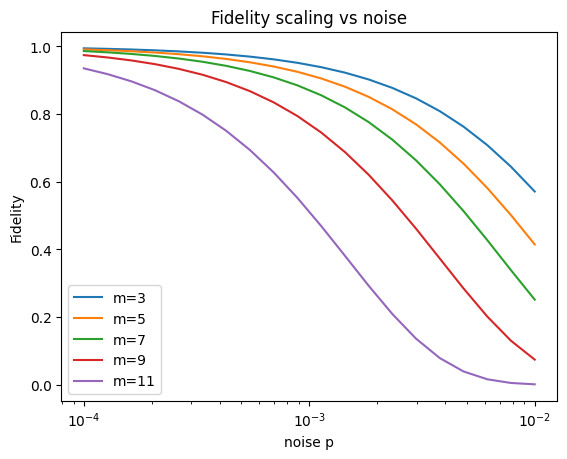

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def G(m):
    return 2**(m-2) + 13*m + 15

def F(m, p, alpha=1.0):
    return np.exp(-alpha * G(m) * p)

m_list = [3, 5, 7, 9, 11]
p_list = np.logspace(-4, -2, 20)

for m in m_list:
    F_vals = [F(m, p) for p in p_list]
    plt.plot(p_list, F_vals, label=f"m={m}")

plt.xscale("log")
plt.xlabel("noise p")
plt.ylabel("Fidelity")
plt.title("Fidelity scaling vs noise")
plt.legend()
plt.show()

In [10]:
import numpy as np

def G(m):
    return 2**(m-2) + 13*m + 15

m = 3   #dati ottenuti da simulazione m=3 
Gm = G(m)

p_vals = np.array([1,0.5,0.2,1e-1,0.05,1e-2,1e-3,1e-4])   # tuoi dati
F_vals = np.array([0.9998149599515428, 0.999961338439746, 0.9999944332080226, 0.9999986554172767, 0.9999996695363444, 
                   0.9999999869593044, 0.9999999998699822, 0.9999999999986919])  # tuoi dati

# evita log(0)
eps = 1e-12

alpha_vals = -np.log(np.clip(F_vals, eps, 1)) / (Gm * p_vals)

alpha_eff = np.mean(alpha_vals)
alpha_std = np.std(alpha_vals)

print("alpha_eff =", alpha_eff)
print("std =", alpha_std)

alpha_eff = 6.957993338647263e-07
std = 1.0766271749936907e-06


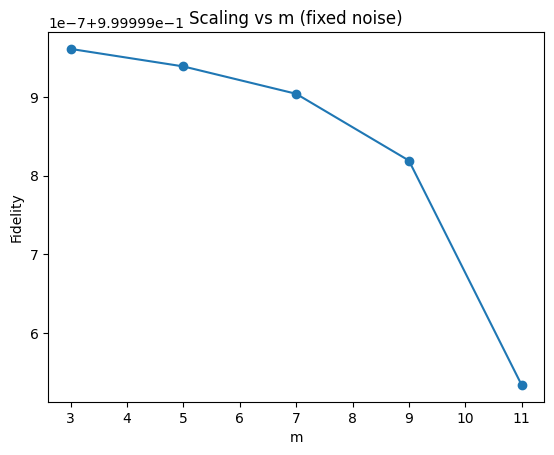

In [11]:
def F_model(m, p, alpha):
    return np.exp(-alpha * G(m) * p)

import matplotlib.pyplot as plt

m_list = [3,5,7,9,11]
p = 1e-3

F_vals = [F_model(m, p, alpha_eff) for m in m_list]

plt.plot(m_list, F_vals, marker='o')
plt.xlabel("m")
plt.ylabel("Fidelity")
plt.title("Scaling vs m (fixed noise)")
plt.show()

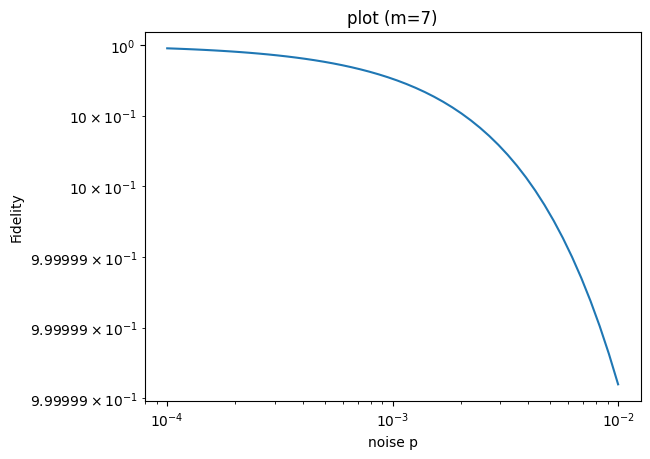

In [19]:
p_list = np.logspace(-4, -2, 50)
m = 7

F_vals = [F_model(m, p, alpha_eff) for p in p_list]

plt.plot(p_list, F_vals)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("noise p")
plt.ylabel("Fidelity")
plt.title(f"plot (m={m})")
plt.show()

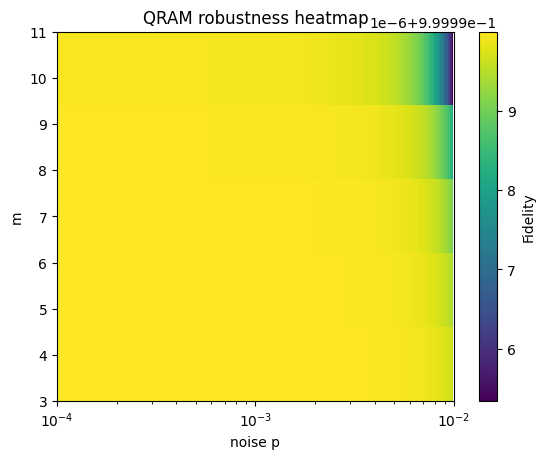

In [13]:
m_list = [3,5,7,9,11]
p_list = np.logspace(-4, -2, 40)

F = np.zeros((len(m_list), len(p_list)))

for i, m in enumerate(m_list):
    for j, p in enumerate(p_list):
        F[i,j] = F_model(m, p, alpha_eff)

plt.imshow(F, aspect='auto', origin='lower',
           extent=[p_list[0], p_list[-1], m_list[0], m_list[-1]])

plt.xscale("log")
plt.colorbar(label="Fidelity")
plt.xlabel("noise p")
plt.ylabel("m")
plt.title("QRAM robustness heatmap")
plt.show()

In [9]:
def shrink_error_probability(error, ratio, verbose=False):
    """
    Scales down noise strength by reducing non-identity probabilities.
    Compatible with modern Qiskit Aer noise models (Kraus / Pauli / mixed forms).
    """

    error_type = error["type"]

    # -------------------------
    # QUANTUM ERROR (gate noise)
    # -------------------------
    if error_type == "qerror":

        probs = error["probabilities"]

        if verbose:
            print("[before]", probs)

        probs = np.array(probs, dtype=float)

        # identity is assumed to be index 0
        non_id_sum = np.sum(probs[1:])

        # scale only non-identity components
        probs[1:] *= ratio

        # renormalize identity
        probs[0] = 1.0 - np.sum(probs[1:])

        # safety clamp
        probs = np.clip(probs, 0.0, 1.0)

        error["probabilities"] = probs.tolist()

        if verbose:
            print("[after]", probs)

    # -------------------------
    # READOUT ERROR
    # -------------------------
    elif error_type == "roerror":

        probs = np.array(error["probabilities"], dtype=float)

        # scale off-diagonal errors
        probs[0][1] *= ratio
        probs[1][0] *= ratio

        probs[0][0] = 1.0 - probs[0][1]
        probs[1][1] = 1.0 - probs[1][0]

        error["probabilities"] = probs.tolist()

    # -------------------------
    # UNKNOWN TYPE
    # -------------------------
    else:
        # do nothing instead of warning spam
        if verbose:
            print(f"[info] skipping unknown error type: {error_type}")

def shrink_probabilities(noise_dict, ratio, verbose=False):

    for error in noise_dict.get("errors", []):
        shrink_error_probability(error, ratio, verbose)

In [12]:
F_bell = []
aver =[]
a  = [1,0.5,0.2,1e-1,0.05,1e-2,1e-3,1e-4]
backend_run = AerSimulator.from_backend(GenericBackendV2(qc.num_qubits))
compiled_circuit = transpile(qc, backend_run)
compiled_circuit.save_statevector()
simulator = AerSimulator()
resulti = simulator.run(compiled_circuit).result()
target_state= resulti.get_statevector(compiled_circuit)
backend_run = GenericBackendV2(qc.num_qubits)
f = open("myfile.txt", "a")


In [ ]:
for y in a:
    F_bell = []
    noise_model = NoiseModel.from_backend(backend_run)
    noise_dict = noise_model.to_dict()
    # print(noise_dict)
    shrink_probabilities(noise_dict, y)
    Reduced_Noise_model=NoiseModel.from_dict(noise_dict)
    sim_noise = AerSimulator(noise_model=Reduced_Noise_model)

    for z in range(5):
        for x in range(10):
            print(f"y = {y} z = {z} x = {x}\n")
            F_bell = []
        # Grab results from the job\n",
            job = sim_noise.run(compiled_circuit)   # submit\n",
            result = job.result()            
            rho_fit= result.get_statevector(compiled_circuit)
            F_bell.append(qi.state_fidelity(rho_fit, target_state)) 
        aver.append(np.average(F_bell))

    f.write(f"State Fidelity: F = {aver}")
    f.write('\n')
f.close()

/tmp/ipykernel_45769/2226853347.py:7: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


y = 1 z = 0 x = 0

y = 1 z = 0 x = 1

y = 1 z = 0 x = 2

y = 1 z = 0 x = 3

y = 1 z = 0 x = 4

y = 1 z = 0 x = 5

y = 1 z = 0 x = 6

y = 1 z = 0 x = 7

y = 1 z = 0 x = 8

y = 1 z = 0 x = 9

y = 1 z = 1 x = 0

y = 1 z = 1 x = 1

y = 1 z = 1 x = 2

y = 1 z = 1 x = 3

y = 1 z = 1 x = 4

y = 1 z = 1 x = 5

y = 1 z = 1 x = 6

y = 1 z = 1 x = 7

y = 1 z = 1 x = 8

y = 1 z = 1 x = 9

y = 1 z = 2 x = 0

y = 1 z = 2 x = 1

y = 1 z = 2 x = 2

y = 1 z = 2 x = 3

y = 1 z = 2 x = 4

y = 1 z = 2 x = 5

y = 1 z = 2 x = 6

y = 1 z = 2 x = 7

y = 1 z = 2 x = 8

y = 1 z = 2 x = 9

y = 1 z = 3 x = 0

y = 1 z = 3 x = 1

y = 1 z = 3 x = 2

y = 1 z = 3 x = 3

y = 1 z = 3 x = 4

y = 1 z = 3 x = 5

y = 1 z = 3 x = 6

y = 1 z = 3 x = 7

y = 1 z = 3 x = 8

y = 1 z = 3 x = 9

y = 1 z = 4 x = 0

y = 1 z = 4 x = 1

y = 1 z = 4 x = 2

y = 1 z = 4 x = 3

y = 1 z = 4 x = 4

y = 1 z = 4 x = 5

y = 1 z = 4 x = 6

y = 1 z = 4 x = 7

y = 1 z = 4 x = 8

y = 1 z = 4 x = 9



/tmp/ipykernel_45769/2226853347.py:7: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


y = 0.5 z = 0 x = 0

y = 0.5 z = 0 x = 1

y = 0.5 z = 0 x = 2

y = 0.5 z = 0 x = 3

y = 0.5 z = 0 x = 4

y = 0.5 z = 0 x = 5

y = 0.5 z = 0 x = 6

y = 0.5 z = 0 x = 7

y = 0.5 z = 0 x = 8

y = 0.5 z = 0 x = 9

y = 0.5 z = 1 x = 0

y = 0.5 z = 1 x = 1

y = 0.5 z = 1 x = 2

y = 0.5 z = 1 x = 3

y = 0.5 z = 1 x = 4

y = 0.5 z = 1 x = 5

y = 0.5 z = 1 x = 6

y = 0.5 z = 1 x = 7

y = 0.5 z = 1 x = 8

y = 0.5 z = 1 x = 9

y = 0.5 z = 2 x = 0

y = 0.5 z = 2 x = 1

y = 0.5 z = 2 x = 2

y = 0.5 z = 2 x = 3

y = 0.5 z = 2 x = 4

y = 0.5 z = 2 x = 5

y = 0.5 z = 2 x = 6

y = 0.5 z = 2 x = 7

y = 0.5 z = 2 x = 8

y = 0.5 z = 2 x = 9

y = 0.5 z = 3 x = 0

y = 0.5 z = 3 x = 1

y = 0.5 z = 3 x = 2

y = 0.5 z = 3 x = 3

y = 0.5 z = 3 x = 4

y = 0.5 z = 3 x = 5

y = 0.5 z = 3 x = 6

y = 0.5 z = 3 x = 7

y = 0.5 z = 3 x = 8

y = 0.5 z = 3 x = 9

y = 0.5 z = 4 x = 0

y = 0.5 z = 4 x = 1

y = 0.5 z = 4 x = 2

y = 0.5 z = 4 x = 3

y = 0.5 z = 4 x = 4

y = 0.5 z = 4 x = 5

y = 0.5 z = 4 x = 6

y = 0.5 z = 4

/tmp/ipykernel_45769/2226853347.py:7: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


...

/tmp/ipykernel_45769/2226853347.py:7: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


y = 0.001 z = 0 x = 0

y = 0.001 z = 0 x = 1

y = 0.001 z = 0 x = 2

y = 0.001 z = 0 x = 3

y = 0.001 z = 0 x = 4

y = 0.001 z = 0 x = 5

y = 0.001 z = 0 x = 6

y = 0.001 z = 0 x = 7

y = 0.001 z = 0 x = 8

y = 0.001 z = 0 x = 9

y = 0.001 z = 1 x = 0

y = 0.001 z = 1 x = 1

y = 0.001 z = 1 x = 2

y = 0.001 z = 1 x = 3

y = 0.001 z = 1 x = 4

y = 0.001 z = 1 x = 5

y = 0.001 z = 1 x = 6

y = 0.001 z = 1 x = 7

y = 0.001 z = 1 x = 8

y = 0.001 z = 1 x = 9

y = 0.001 z = 2 x = 0

y = 0.001 z = 2 x = 1

y = 0.001 z = 2 x = 2

y = 0.001 z = 2 x = 3

y = 0.001 z = 2 x = 4

y = 0.001 z = 2 x = 5

y = 0.001 z = 2 x = 6

y = 0.001 z = 2 x = 7

y = 0.001 z = 2 x = 8

y = 0.001 z = 2 x = 9

y = 0.001 z = 3 x = 0

y = 0.001 z = 3 x = 1

y = 0.001 z = 3 x = 2

y = 0.001 z = 3 x = 3

y = 0.001 z = 3 x = 4

y = 0.001 z = 3 x = 5

y = 0.001 z = 3 x = 6

y = 0.001 z = 3 x = 7

y = 0.001 z = 3 x = 8

y = 0.001 z = 3 x = 9

y = 0.001 z = 4 x = 0

y = 0.001 z = 4 x = 1

y = 0.001 z = 4 x = 2

y = 0.001 z

/tmp/ipykernel_45769/2226853347.py:7: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


y = 0.0001 z = 0 x = 0



: 

In [ ]:
plot_histogram(result.get_counts(compiled_circuit))